# FOV review and expansion

The original strip-assignment batch (02b) retained 6 of 13 S1 FOVs (4, 5, 8, 9, 10, 11).
Seven were excluded:

| FOV | Transcripts | Reason logged |
|-----|-------------|---------------|
| 1   | 27,425      | missing strips / bad mapping |
| 2   | 64,875      | missing strips / bad mapping |
| 3   | 72,701      | separate parquet; fourth tissue section |
| 6   | 54,138      | missing strips / bad mapping |
| 7   | 43,673      | missing strips / bad mapping |
| 12  | 39,823      | missing strips / bad mapping |
| 13  | 7,878       | spatial outlier, isolated |

FOV 13 is re-excluded here (too sparse). FOV 3 is included from its existing parquet
(the fourth tissue section will be handled per-analysis by the custom window in 09b).
FOVs 1, 2, 6, 7, 12 are reviewed visually below â€” inspect the plots and update
`fov_config` in **Section 2** before running the GMM loop.

**Outputs:**
- `data/processed/s1_expanded_strips.parquet` â€” all included FOVs, strip-assigned
- `data/processed/s1_expanded_strips_noise_flagged.parquet` â€” after DBSCAN QC

## Imports

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import spatialdata as sd
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

EXCLUDED_FOVS = [1, 2, 6, 7, 12]  # candidates for re-inclusion
EXISTING_FOVS = [4, 5, 8, 9, 10, 11]

STRIP_LABELS  = {0: 'strip_1', 1: 'strip_2', 2: 'strip_3'}
STRIP_COLOURS = {'strip_1': 'steelblue', 'strip_2': 'tomato', 'strip_3': 'seagreen'}

X_COL = 'x_global_px'
Y_COL = 'y_global_px'

c:\Users\Harry\Desktop\NoSegs_Project\cosmx-pointpattern\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\Harry\Desktop\NoSegs_Project\cosmx-pointpattern\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
c:\Users\Harry\Desktop\NoSegs_Project\cosmx-pointpattern\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_joi

## Section 1: Data loading

In [2]:
sdata_s1 = sd.read_zarr('../data/raw/updated_stitched_S1.zarr')
s1_pts = sdata_s1.points['points'].compute()
print(f'S1 total transcripts: {len(s1_pts):,}')
print(f'FOVs in zarr: {sorted(s1_pts["fov"].unique())}')

C:\Users\Harry\AppData\Local\Temp\ipykernel_16360\2000564260.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata_s1 = sd.read_zarr('../data/raw/updated_stitched_S1.zarr')
no parent found for <ome_zarr.reader.Label object at 0x00000228034078C0>: None


S1 total transcripts: 710,751
FOVs in zarr: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


In [3]:
# Existing processed data (reference only â€” not modified)
s1_existing = pd.read_parquet('../data/processed/s1_all_strips.parquet')
fov3 = pd.read_parquet('../data/processed/fov3_strips.parquet')

print(f'Existing strips parquet: {len(s1_existing):,} transcripts, FOVs {sorted(s1_existing["fov"].unique())}')
print(f'FOV3 parquet:            {len(fov3):,} transcripts')
print(f'Columns in existing:     {list(s1_existing.columns)}')

# Target schema â€” 13 columns, matching s1_all_strips.parquet
TARGET_COLS = list(s1_existing.columns)

Existing strips parquet: 400,238 transcripts, FOVs [np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
FOV3 parquet:            72,701 transcripts
Columns in existing:     ['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed', 'strip']


## Section 2: Visual review of excluded FOVs

Each row shows the spatial scatter and local x-histogram for one excluded FOV.
Look for clear trimodal structure in the histogram â€” three visible peaks indicate
separable strips. A flat or bimodal distribution suggests the FOV sits at the tissue
edge and may only have 2 strips.

**After inspecting the plots, update `fov_config` in the next cell.**

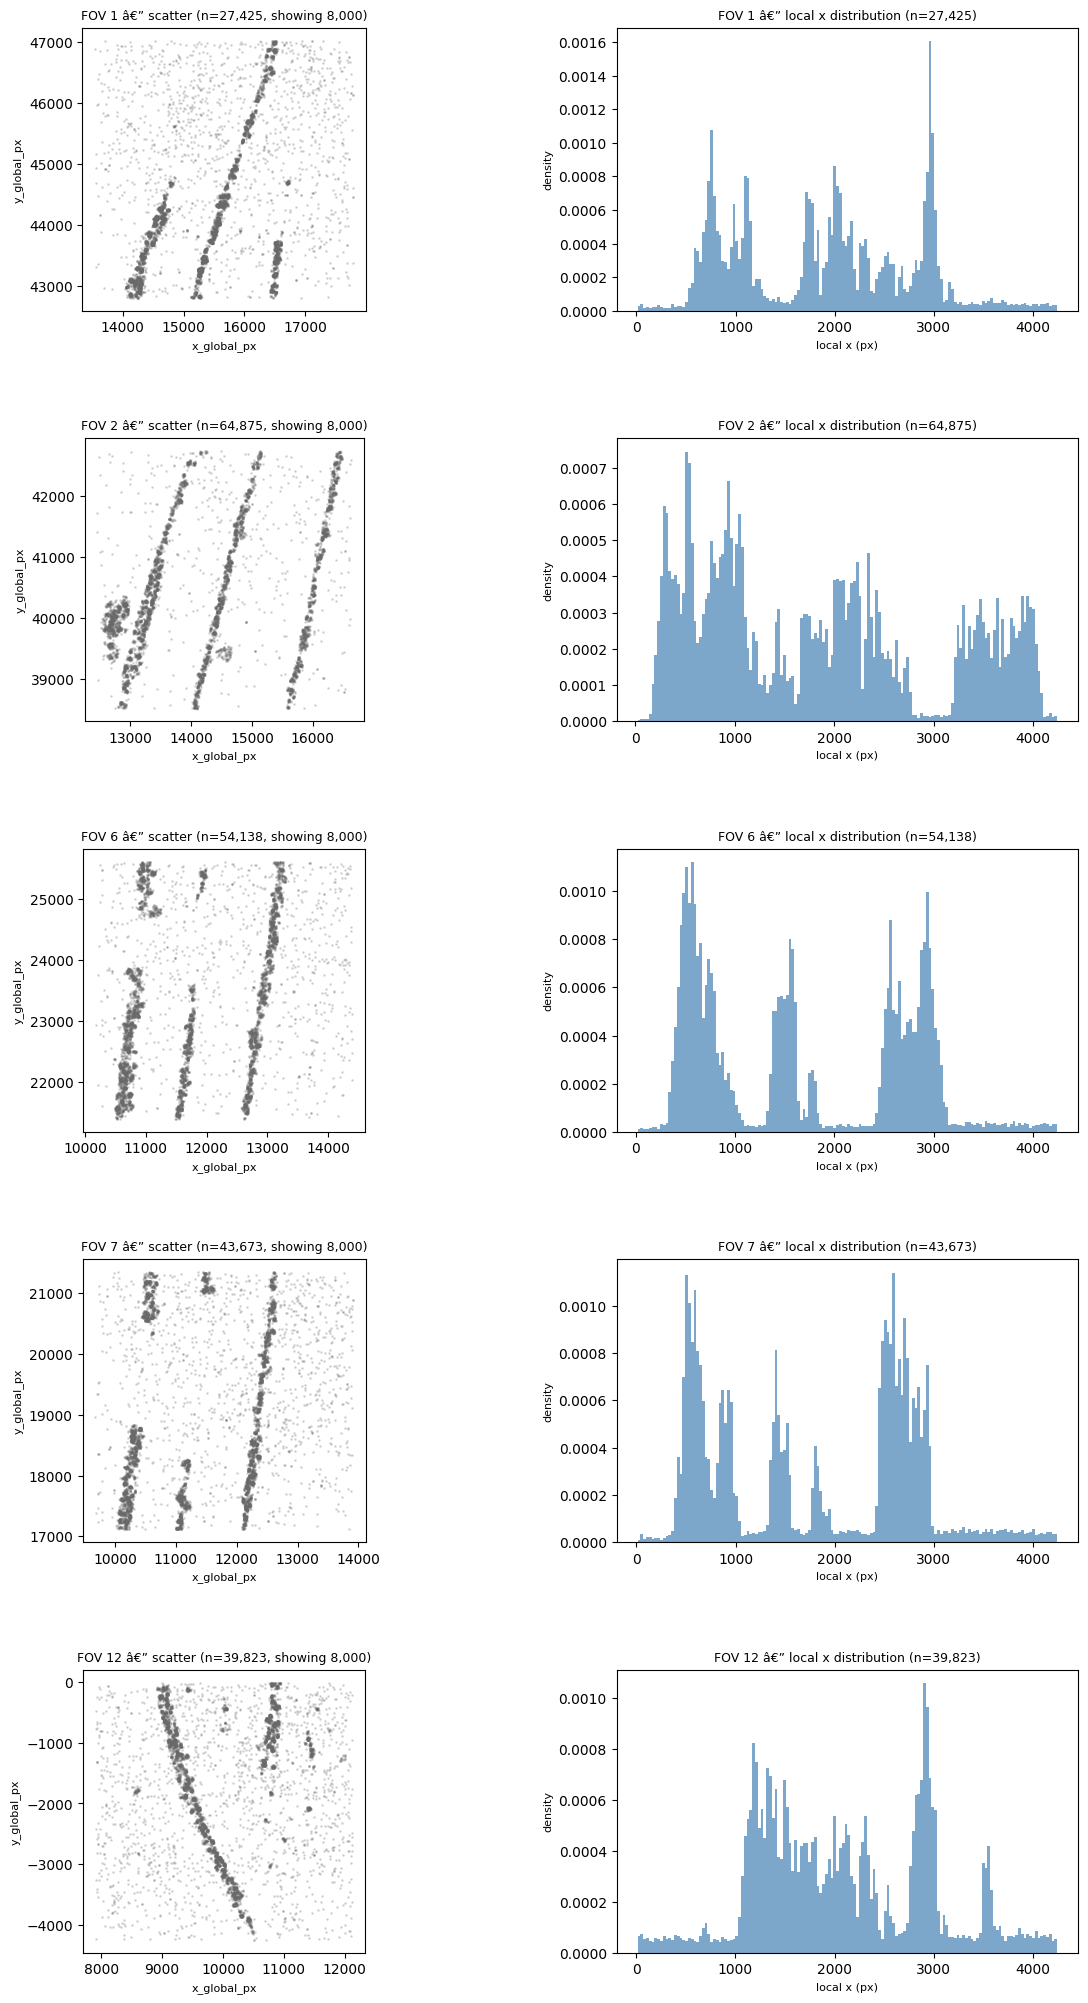

In [4]:
rng_vis = np.random.default_rng(0)
N_SAMPLE = 8_000

n_fovs = len(EXCLUDED_FOVS)
fig = plt.figure(figsize=(14, 5 * n_fovs))
gs = gridspec.GridSpec(n_fovs, 2, figure=fig, hspace=0.45, wspace=0.35)

for row, fov_id in enumerate(EXCLUDED_FOVS):
    fov_df = s1_pts[s1_pts['fov'] == fov_id]
    coords = fov_df[[X_COL, Y_COL]].values
    n_total = len(fov_df)

    # Scatter
    ax_scatter = fig.add_subplot(gs[row, 0])
    n_show = min(n_total, N_SAMPLE)
    idx = rng_vis.choice(n_total, n_show, replace=False)
    ax_scatter.scatter(coords[idx, 0], coords[idx, 1],
                       s=1, alpha=0.2, c='dimgrey', rasterized=True)
    ax_scatter.set_aspect('equal')
    ax_scatter.set_title(f'FOV {fov_id} â€” scatter (n={n_total:,}, showing {n_show:,})', fontsize=9)
    ax_scatter.set_xlabel(X_COL, fontsize=8)
    ax_scatter.set_ylabel(Y_COL, fontsize=8)

    # x-histogram
    ax_hist = fig.add_subplot(gs[row, 1])
    ax_hist.hist(fov_df['x'], bins=150, color='steelblue', alpha=0.7,
                 edgecolor='none', density=True)
    ax_hist.set_title(f'FOV {fov_id} â€” local x distribution (n={n_total:,})', fontsize=9)
    ax_hist.set_xlabel('local x (px)', fontsize=8)
    ax_hist.set_ylabel('density', fontsize=8)

plt.savefig('../results/figures/02c_excluded_fov_review.png', dpi=120, bbox_inches='tight')
plt.show()

### `fov_config` â€” update based on the review plots above

Set `True` to include, `False` to exclude.

In [5]:
# ---- EDIT THIS DICT after reviewing the plots above ----
fov_config = {
    1:  True,   # 27,425 transcripts â€” small, check for trimodal structure
    2:  True,   # 64,875
    6:  True,   # 54,138
    7:  True,   # 43,673
    12: True,   # 39,823
    # FOV 13 not listed â€” excluded regardless (7,878 transcripts, spatial outlier)
}
# ---------------------------------------------------------

fovs_to_process = [fov_id for fov_id, include in fov_config.items() if include]
print(f'FOVs to process via GMM: {fovs_to_process}')
print(f'FOVs skipped: {[f for f, inc in fov_config.items() if not inc]}')

FOVs to process via GMM: [1, 2, 6, 7, 12]
FOVs skipped: []


## Section 3: GMM strip assignment for newly included FOVs

Fits a 3-component GMM to the local `x` coordinate for each included FOV.
Components are ordered left-to-right (strip_1 = leftmost, strip_3 = rightmost).
Confirmation plots are shown after each assignment.

If a FOV's histogram showed fewer than 3 clear modes, set it to `False` in
`fov_config` above and re-run from that cell.


FOV 1 â€” 27,425 transcripts
  Strip counts: {'strip_1': 9709, 'strip_2': 8847, 'strip_3': 8869}


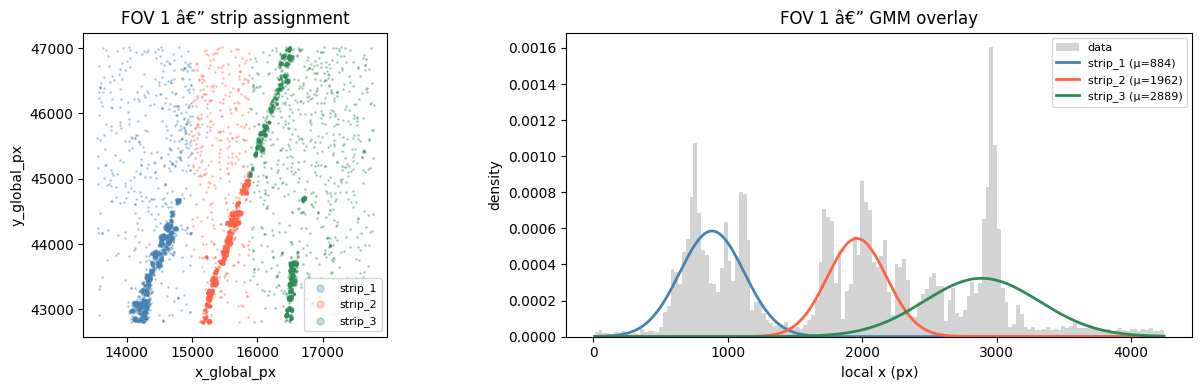


FOV 2 â€” 64,875 transcripts
  Strip counts: {'strip_1': 28411, 'strip_2': 21720, 'strip_3': 14744}


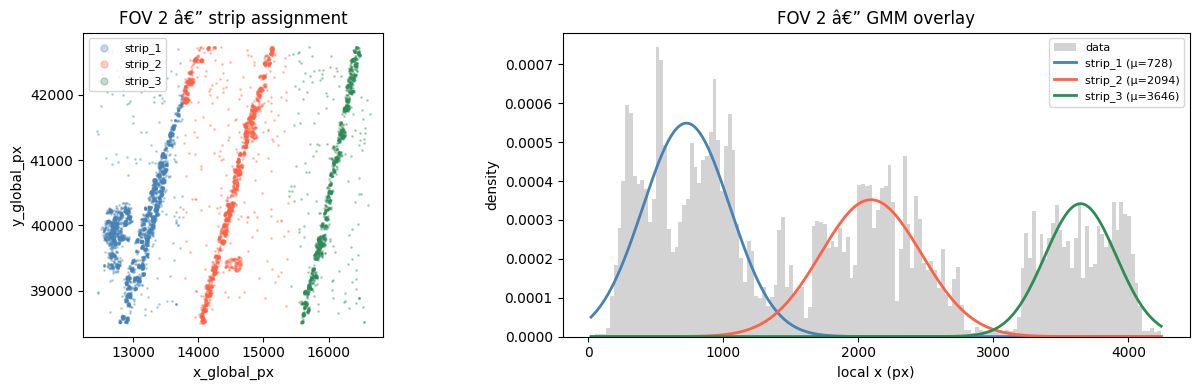


FOV 6 â€” 54,138 transcripts
  Strip counts: {'strip_1': 21777, 'strip_2': 10706, 'strip_3': 21655}


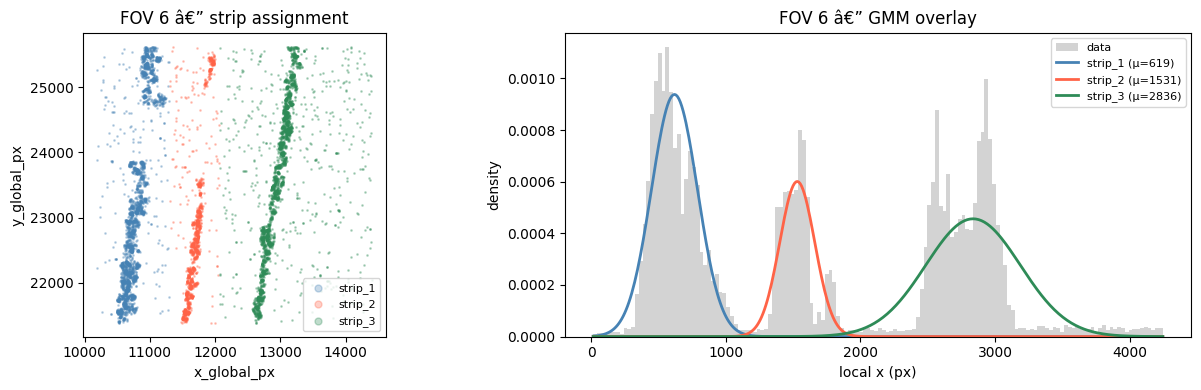


FOV 7 â€” 43,673 transcripts
  Strip counts: {'strip_1': 23911, 'strip_2': 17633, 'strip_3': 2129}


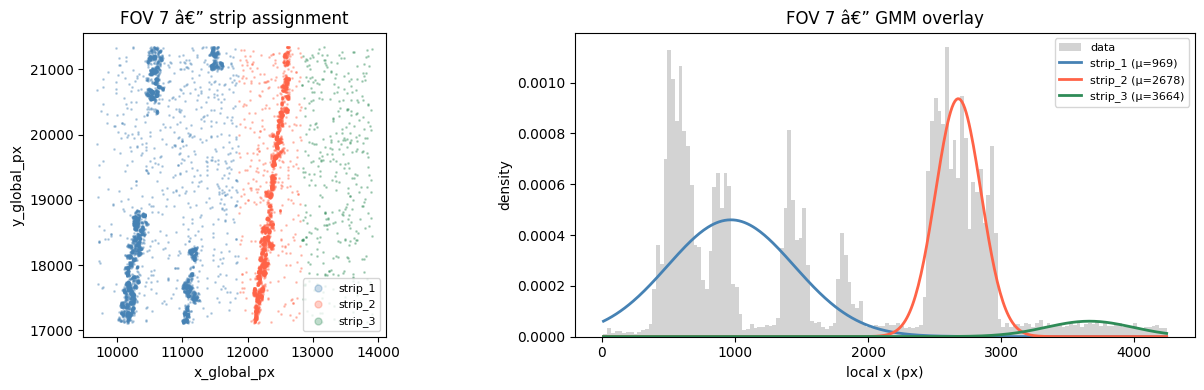


FOV 12 â€” 39,823 transcripts
  Strip counts: {'strip_1': 23166, 'strip_2': 13422, 'strip_3': 3235}


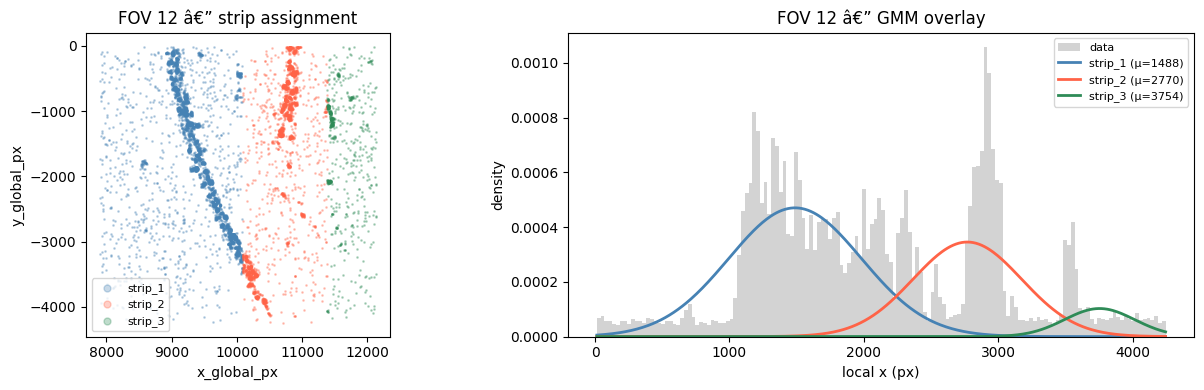


GMM assignment complete.


In [6]:
new_fov_dfs = []

for fov_id in fovs_to_process:
    fov_df = s1_pts[s1_pts['fov'] == fov_id].copy()
    n = len(fov_df)
    print(f'\nFOV {fov_id} â€” {n:,} transcripts')

    # GMM on local x
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm.fit(fov_df[['x']])

    # Order components left to right by mean x
    order = np.argsort(gmm.means_.flatten())
    probs = gmm.predict_proba(fov_df[['x']])
    probs_ordered = probs[:, order]
    strip_idx = np.argmax(probs_ordered, axis=1)
    fov_df['strip'] = [STRIP_LABELS[i] for i in strip_idx]

    print(f'  Strip counts: {fov_df["strip"].value_counts().sort_index().to_dict()}')

    # Confirmation plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    rng_conf = np.random.default_rng(fov_id)
    n_show = min(n, 8_000)
    idx_s = rng_conf.choice(n, n_show, replace=False)
    sub = fov_df.iloc[idx_s]
    for strip, grp in sub.groupby('strip'):
        axes[0].scatter(grp[X_COL], grp[Y_COL],
                        s=1, alpha=0.3,
                        c=STRIP_COLOURS.get(strip, 'grey'),
                        label=strip, rasterized=True)
    axes[0].set_aspect('equal')
    axes[0].set_title(f'FOV {fov_id} â€” strip assignment')
    axes[0].set_xlabel(X_COL)
    axes[0].set_ylabel(Y_COL)
    axes[0].legend(fontsize=8, markerscale=5)

    x_vals = fov_df['x'].values
    x_range = np.linspace(x_vals.min(), x_vals.max(), 400)
    axes[1].hist(x_vals, bins=150, density=True, color='lightgrey',
                 edgecolor='none', label='data')
    for rank, comp_idx in enumerate(order):
        mu    = gmm.means_[comp_idx, 0]
        sigma = np.sqrt(gmm.covariances_[comp_idx, 0, 0])
        weight = gmm.weights_[comp_idx]
        gauss = weight / (sigma * np.sqrt(2 * np.pi)) * np.exp(
            -0.5 * ((x_range - mu) / sigma) ** 2
        )
        axes[1].plot(x_range, gauss,
                     color=list(STRIP_COLOURS.values())[rank],
                     lw=2, label=f'{STRIP_LABELS[rank]} (\u03bc={mu:.0f})')
    axes[1].set_title(f'FOV {fov_id} â€” GMM overlay')
    axes[1].set_xlabel('local x (px)')
    axes[1].set_ylabel('density')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'../results/figures/02c_fov{fov_id}_gmm.png', dpi=120)
    plt.show()

    new_fov_dfs.append(fov_df)

print('\nGMM assignment complete.')

## Section 4: Merge and save

Combines:
- `s1_all_strips.parquet` (FOVs 4, 5, 8, 9, 10, 11)
- `fov3_strips.parquet` (FOV 3, trimmed to shared 13-column schema)
- Newly assigned FOVs from Section 3

All DataFrames are aligned to the 13-column schema before concatenation.

In [7]:
print(f'Target schema ({len(TARGET_COLS)} cols):', TARGET_COLS)

# FOV3: drop strip_confidence and strip_ambiguous to match schema
fov3_trimmed = fov3[TARGET_COLS].copy()
print(f'FOV3 trimmed:  {len(fov3_trimmed):,} rows')

# Newly processed FOVs
if new_fov_dfs:
    new_combined = pd.concat(
        [df[TARGET_COLS] for df in new_fov_dfs],
        ignore_index=True
    )
else:
    new_combined = pd.DataFrame(columns=TARGET_COLS)
print(f'New FOVs:      {len(new_combined):,} rows')

# Concatenate everything
s1_expanded = pd.concat(
    [s1_existing, fov3_trimmed, new_combined],
    ignore_index=True
)

print(f'\nExpanded total: {len(s1_expanded):,} transcripts')
print(f'FOVs: {sorted(s1_expanded["fov"].unique())}')
print(f'\nPer-FOV, per-strip counts:')
print(s1_expanded.groupby(['fov', 'strip']).size().unstack(fill_value=0).to_string())

Target schema (13 cols): ['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed', 'strip']
FOV3 trimmed:  72,701 rows
New FOVs:      229,934 rows

Expanded total: 702,873 transcripts
FOVs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Per-FOV, per-strip counts:
strip  strip_1  strip_2  strip_3
fov                             
1         9709     8847     8869
2        28411    21720    14744
3        37870    18283    16548
4        30382    18333    18698
5        28519    17265    18086
6        21777    10706    21655
7        23911    17633     2129
8        29523    19707    19068
9        32115    17864    19772
10       28888    18931    20827
11       28872    14829    18559
12       23166    13422     3235


In [8]:
s1_expanded.to_parquet('../data/processed/s1_expanded_strips.parquet', index=False)
print('Saved: data/processed/s1_expanded_strips.parquet')

Saved: data/processed/s1_expanded_strips.parquet


## Section 5: DBSCAN noise filtering

Applies adaptive DBSCAN (1-NN p97, eps clipped to [20, 30], min_samples=5,
grouped by `[fov, strip]`) to the full expanded dataset.

The function is defined here directly rather than via `%run 08_improved_QC.ipynb`
to avoid re-running nb08's exploratory cells. The implementation and parameters
are identical to nb08; the only addition is a `summary` return value for comparison
against the nb08 baseline (6.8% noise overall).

In [9]:
def dbscan_noise_filter(
    df,
    x_col='x_global_px_transformed',
    y_col='y_global_px_transformed',
    group_cols=None,
    percentile=97,
    eps_floor=20,
    eps_ceiling=30,
    min_samples=5,
    diagnostics=False,
):
    """
    Flag spatial noise transcripts using adaptive DBSCAN.

    Derives eps per group from the 1-NN distance distribution at a given
    percentile, clipped to [eps_floor, eps_ceiling]. Points labelled as
    DBSCAN noise (cluster = -1) are flagged but not removed.

    Parameters
    ----------
    df : pd.DataFrame
    x_col, y_col : str
    group_cols : list of str or None
    percentile : float
    eps_floor, eps_ceiling : float
    min_samples : int
    diagnostics : bool

    Returns
    -------
    result : pd.DataFrame
        Copy of input with added columns: dbscan_label, is_noise, eps_used, eps_raw.
    summary : pd.DataFrame
        Per-group noise rate table.
    """
    result = df.copy()
    result['dbscan_label'] = -1
    result['is_noise'] = True
    result['eps_used'] = np.nan
    result['eps_raw'] = np.nan

    if group_cols is None:
        group_cols = ['_dummy']
        result['_dummy'] = 'all'

    groups = result.groupby(group_cols)
    n_groups = len(groups)
    summary_records = []

    if diagnostics:
        n_cols = min(3, n_groups)
        n_rows = int(np.ceil(n_groups / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
        if n_groups == 1:
            axes = np.array([axes])
        axes = axes.ravel()

    for i, (group_key, group_df) in enumerate(groups):
        idx = group_df.index
        coords = group_df[[x_col, y_col]].values

        nn = NearestNeighbors(n_neighbors=2).fit(coords)
        distances, _ = nn.kneighbors(coords)
        nn_dist = distances[:, 1]
        raw_eps = np.percentile(nn_dist, percentile)
        eps = np.clip(raw_eps, eps_floor, eps_ceiling)

        db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
        labels = db.labels_
        noise_mask = labels == -1

        result.loc[idx, 'dbscan_label'] = labels
        result.loc[idx, 'is_noise']     = noise_mask
        result.loc[idx, 'eps_used']     = eps
        result.loc[idx, 'eps_raw']      = raw_eps

        n_noise = int(noise_mask.sum())
        pct = 100 * n_noise / len(labels)
        label = group_key if isinstance(group_key, str) else ', '.join(str(g) for g in group_key)
        summary_records.append({
            'group':     label,
            'n_total':   len(labels),
            'n_noise':   n_noise,
            'pct_noise': round(pct, 1),
            'eps_raw':   round(raw_eps, 1),
            'eps_used':  round(eps, 1),
        })

        if diagnostics:
            ax = axes[i]
            ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
                       s=0.3, alpha=0.3, c='steelblue', label='kept')
            ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
                       s=2, alpha=0.8, c='red', label='noise')
            ax.set_title(f'{label}\neps={eps:.1f} (raw={raw_eps:.1f}) | {n_noise} noise ({pct:.1f}%)')
            ax.set_aspect('equal')
            ax.legend(markerscale=5, fontsize=7)

    if '_dummy' in result.columns:
        result.drop(columns='_dummy', inplace=True)

    if diagnostics:
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    return result, pd.DataFrame(summary_records)

In [10]:
print(f'Running DBSCAN on {len(s1_expanded):,} transcripts grouped by [fov, strip]...')
t0 = time.time()

s1_expanded_flagged, noise_summary = dbscan_noise_filter(
    s1_expanded,
    group_cols=['fov', 'strip'],
)

print(f'Done in {time.time() - t0:.1f}s')

Running DBSCAN on 702,873 transcripts grouped by [fov, strip]...
Done in 5.8s


In [11]:
print('Noise summary by FOV and strip:')
print(noise_summary.to_string(index=False))

n_total = len(s1_expanded_flagged)
n_noise = int(s1_expanded_flagged['is_noise'].sum())
n_kept  = n_total - n_noise
print(f'\nTotal:   {n_total:,}')
print(f'Noise:   {n_noise:,} ({100 * n_noise / n_total:.1f}%)')
print(f'Kept:    {n_kept:,}')
print(f'\nnb08 baseline: 27,313 / 400,238 = 6.8% noise (6 FOVs)')

Noise summary by FOV and strip:
      group  n_total  n_noise  pct_noise  eps_raw  eps_used
 1, strip_1     9709     1176       12.1     42.1      30.0
 1, strip_2     8847      851        9.6     35.0      30.0
 1, strip_3     8869     1853       20.9     47.2      30.0
 2, strip_1    28411      867        3.1     11.0      20.0
 2, strip_2    21720     1287        5.9     26.6      26.6
 2, strip_3    14744      903        6.1     28.1      28.1
 3, strip_1    37870     1169        3.1     10.0      20.0
 3, strip_2    18283     1085        5.9     27.6      27.6
 3, strip_3    16548     1021        6.2     26.7      26.7
 4, strip_1    30382      813        2.7      9.2      20.0
 4, strip_2    18333     1098        6.0     22.5      22.5
 4, strip_3    18698     1336        7.1     29.6      29.6
 5, strip_1    28519      742        2.6      9.2      20.0
 5, strip_2    17265      894        5.2     17.7      20.0
 5, strip_3    18086     1562        8.6     32.3      30.0
 6, stri

In [12]:
# Schema: TARGET_COLS + DBSCAN columns, matching s1_all_strips_noise_flagged.parquet
save_cols = TARGET_COLS + ['dbscan_label', 'is_noise', 'eps_used', 'eps_raw']
s1_expanded_flagged[save_cols].to_parquet(
    '../data/processed/s1_expanded_strips_noise_flagged.parquet',
    index=False
)
print('Saved: data/processed/s1_expanded_strips_noise_flagged.parquet')
print(f'Columns ({len(save_cols)}): {save_cols}')

Saved: data/processed/s1_expanded_strips_noise_flagged.parquet
Columns (17): ['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed', 'strip', 'dbscan_label', 'is_noise', 'eps_used', 'eps_raw']


## Section 6: Overview plot

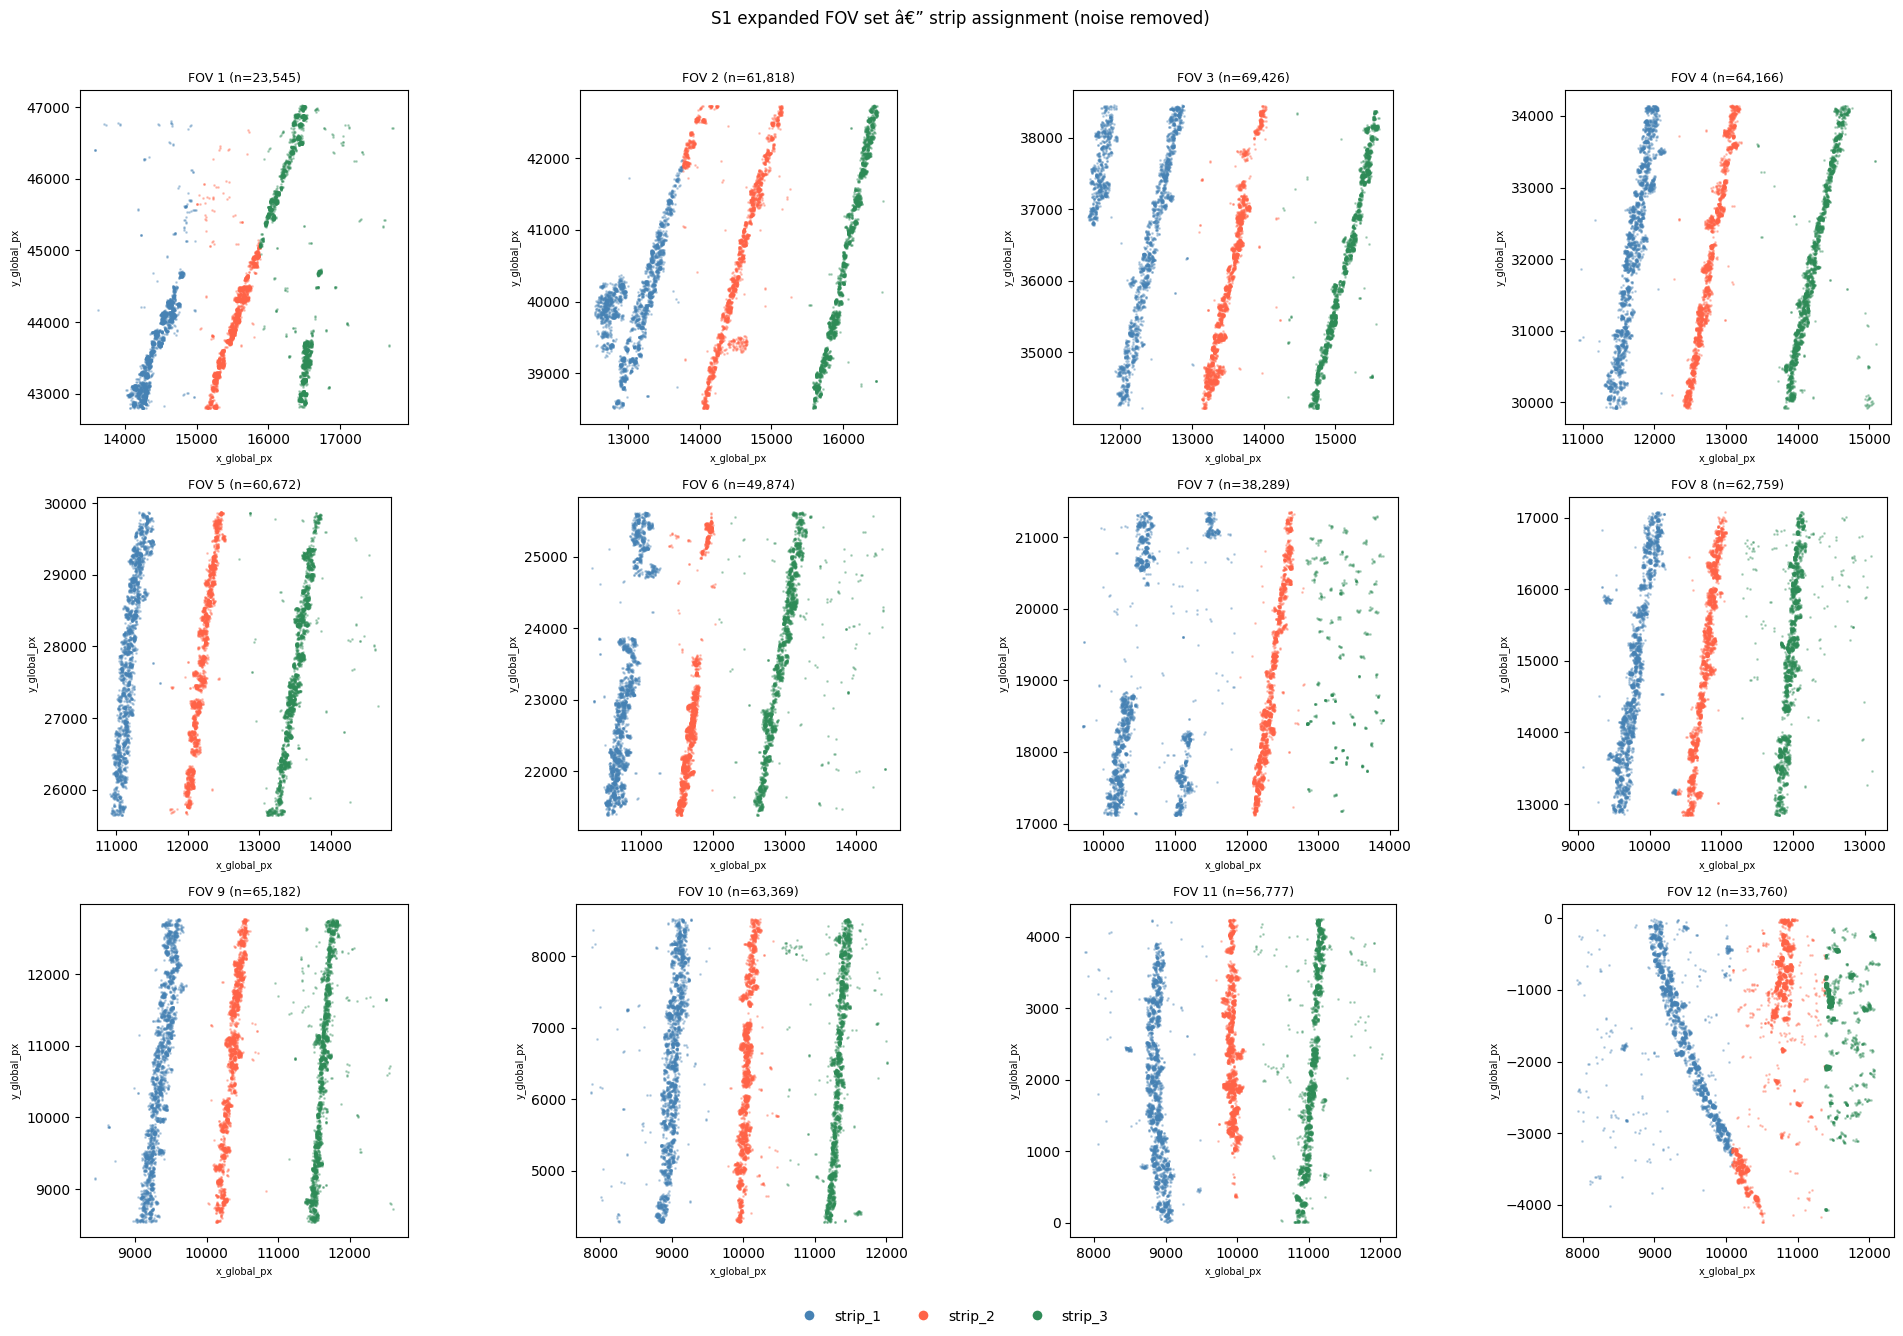

Final expanded dataset: 649,637 transcripts across 12 FOVs


In [13]:
clean = s1_expanded_flagged[~s1_expanded_flagged['is_noise']]
fovs_all = sorted(clean['fov'].unique())
n_fovs_all = len(fovs_all)

n_cols_ov = min(4, n_fovs_all)
n_rows_ov = int(np.ceil(n_fovs_all / n_cols_ov))
fig, axes = plt.subplots(n_rows_ov, n_cols_ov,
                          figsize=(5 * n_cols_ov, 4.5 * n_rows_ov))
axes = np.array(axes).ravel()

rng_ov = np.random.default_rng(0)

for ax, fov_id in zip(axes, fovs_all):
    fov_clean = clean[clean['fov'] == fov_id]
    for strip in ['strip_1', 'strip_2', 'strip_3']:
        grp = fov_clean[fov_clean['strip'] == strip]
        if len(grp) == 0:
            continue
        n_show = min(len(grp), 3_000)
        idx_s = rng_ov.choice(len(grp), n_show, replace=False)
        ax.scatter(
            grp.iloc[idx_s][X_COL], grp.iloc[idx_s][Y_COL],
            s=1, alpha=0.3,
            c=STRIP_COLOURS.get(strip, 'grey'),
            label=strip, rasterized=True
        )
    ax.set_title(f'FOV {fov_id} (n={len(fov_clean):,})', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel(X_COL, fontsize=7)
    ax.set_ylabel(Y_COL, fontsize=7)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=STRIP_COLOURS[s], markersize=8, label=s)
           for s in ['strip_1', 'strip_2', 'strip_3']]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10, frameon=False)

for ax in axes[n_fovs_all:]:
    ax.set_visible(False)

fig.suptitle('S1 expanded FOV set â€” strip assignment (noise removed)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('../results/figures/02c_expanded_fovs_overview.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Final expanded dataset: {len(clean):,} transcripts across {n_fovs_all} FOVs')